## Import data dulu guys

array([[<Axes: title={'center': 'HouseSize'}>,
        <Axes: title={'center': 'DistanceToCity'}>],
       [<Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'SchoolScore'}>],
       [<Axes: title={'center': 'Bedrooms'}>,
        <Axes: title={'center': 'Price'}>]], dtype=object)

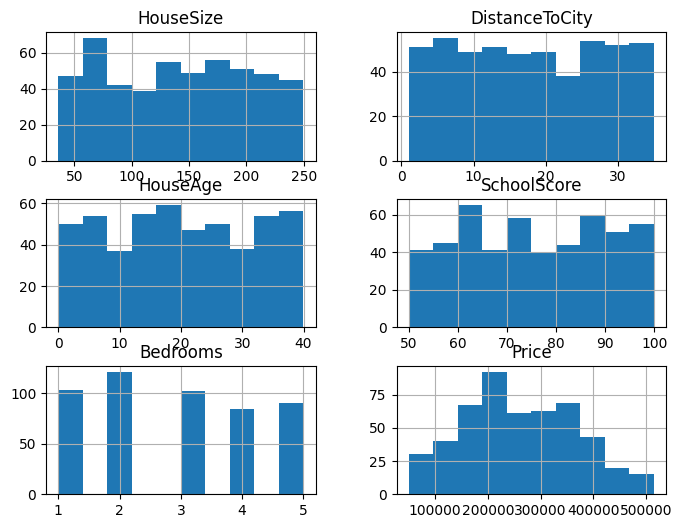

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv").set_index("Id")

df.hist(figsize=(8, 6))

In [3]:
df

,HouseSize,DistanceToCity,HouseAge,SchoolScore,Bedrooms,Price
Id,,,,,,
1,201.40,26.05,2.48,83.59,2,334545.54
2,129.36,31.14,18.33,98.03,5,231072.08
3,219.60,32.32,5.16,68.55,1,311795.78
4,184.93,18.12,6.09,71.25,3,351532.22
5,55.25,18.69,25.29,90.61,5,204863.13
...,...,...,...,...,...,...
496,153.07,15.89,25.52,87.69,4,326101.82
497,127.75,22.73,34.25,64.26,2,179167.27
498,169.59,1.08,25.24,66.75,2,329513.41


## Kita pisah ke x dan y

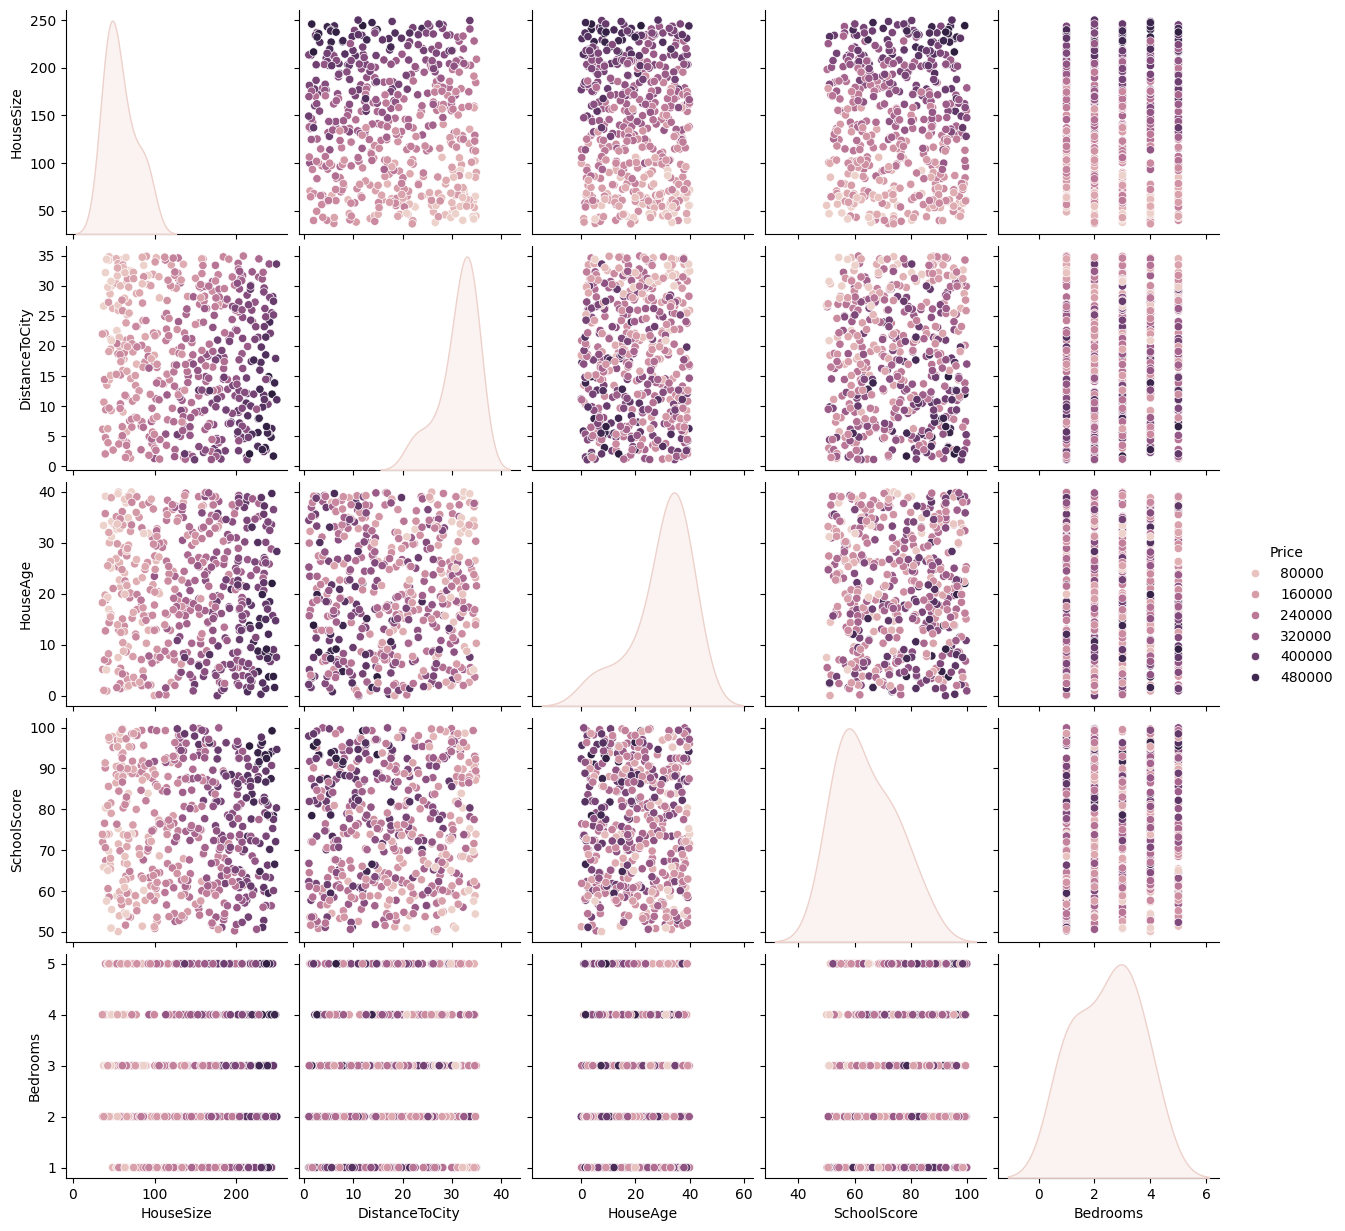

In [4]:
x, y = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

sns.pairplot(data=df, hue="Price")

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet
from sklearn.decomposition import PCA

pipes = Pipeline([
    ("s1", StandardScaler()),
    ("pt", PowerTransformer(method="yeo-johnson")),
    ("s2", StandardScaler()),
    ("pf", PolynomialFeatures(degree=2, interaction_only=True)),
    ("s3", StandardScaler()),
    ("skb", SelectKBest(score_func=f_regression, k=21)),
    # ("lr", ElasticNet()),
    # ("pca", PCA()),
    ("lr", LinearRegression()),
])
kf = KFold(n_splits=8, shuffle=True, random_state=67)

gscvs = GridSearchCV(
    estimator=pipes,
    param_grid={
        # "skb__k": [10],
        # "pf__interaction_only": [True],
        "pf__degree": [2],
        "skb__k": np.arange(1, 22, 1),
        "pf__interaction_only": [False],
        # "pca__n_components": np.arange(1, 13, 1),
        # "lr__alpha": np.logspace(-4, 2, 7),
        # "lr__l1_ratio": np.logspace(-2, 2, 5),
        # "lr__n_neighbors": np.arange(1, 21, 1),
    },
    cv=kf,
    # scoring="neg_root_mean_squared_error"
)
gscvs.fit(x, y)
print(gscvs.best_params_)
print(gscvs.best_score_)

bestmodels = gscvs.best_estimator_

{'pf__degree': 2, 'pf__interaction_only': False, 'skb__k': np.int64(16)}
0.9391071518293447


In [60]:
dfx = pd.read_csv("test.csv").set_index("Id")
xsub = dfx.to_numpy()

ysub = bestmodels.predict(xsub)

dfy = pd.Series(ysub, index=dfx.index, name="Price")

dfy.to_csv("submission.csv")

from sklearn.metrics import r2_score
print(r2_score(y, dfy))

dfy

-0.961213460808064


Id
501     203966.048084
502     271283.210366
503     224166.736344
504     428619.306968
505     253938.647619
            ...      
996     275650.464106
997     133657.647123
998     211422.550603
999      46230.565992
1000    320466.869104
Name: Price, Length: 500, dtype: float64